# LSTM Caption Decoder

**Outputs saved to** `My Drive/Healix/outputs/decoder/`

In [1]:
# Verify GPU is available
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print('GPUs available:', gpus)
print('TF version:', tf.__version__)

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF version: 2.20.0


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [3]:
%pip install -q nltk

# Imports

In [4]:
import re
import json
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

import nltk
from nltk.translate.bleu_score import corpus_bleu
nltk.download('punkt', quiet=True)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, SpatialDropout1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import load_img

print('All imports OK')

All imports OK


# Configuration

In [5]:
# ── Paths (Google Drive) ──────────────────────────────────────────────────────
DRIVE_DIR      = Path('/content/drive/MyDrive/Healix')
CAPTIONS_FILE  = DRIVE_DIR / 'captions.txt'
FEATURES_FILE  = DRIVE_DIR / 'all_features.npy'
OUTPUT_DIR     = DRIVE_DIR / 'outputs' / 'decoder'

# ── Training config ───────────────────────────────────────────────────────────
NUM_IMAGES     = None   # use all 8091 images
EPOCHS         = 20

# ── Hyperparameters ───────────────────────────────────────────────────────────
VOCAB_MIN_FREQ = 5
MAX_LEN        = 35
EMBEDDING_DIM  = 100    # must match GloVe dimension (100d)
LSTM_UNITS     = 512    # larger model = better capacity
BATCH_SIZE     = 128    # larger batch = faster on GPU

print(f'NUM_IMAGES={NUM_IMAGES}  |  EPOCHS={EPOCHS}  |  BATCH_SIZE={BATCH_SIZE}'  )
print(f'Captions file exists : {CAPTIONS_FILE.exists()}')
print(f'Features file exists : {FEATURES_FILE.exists()}')

NUM_IMAGES=None  |  EPOCHS=20  |  BATCH_SIZE=128
Captions file exists : True
Features file exists : True


# Step 1 — Load Captions

In [6]:
captions_dict = {}

with open(CAPTIONS_FILE, encoding='utf-8') as f:
    next(f)  # skip header
    for line in f:
        line = line.strip()
        if not line:
            continue
        comma = line.index(',')
        img_name = line[:comma]
        caption  = line[comma + 1:]
        captions_dict.setdefault(img_name, []).append(caption)

all_image_names = sorted(captions_dict.keys())
print(f'Total images   : {len(all_image_names)}')
print(f'Total captions : {sum(len(v) for v in captions_dict.values())}')

Total images   : 8091
Total captions : 40455


# Step 2 — Clean & Tokenize

In [7]:
def clean(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return 'startseq ' + text + ' endseq'


def pad_seq(seq: list, maxlen: int) -> list:
    seq = seq[:maxlen]
    return seq + [0] * (maxlen - len(seq))


word_freq = Counter()
for caps in captions_dict.values():
    for cap in caps:
        word_freq.update(clean(cap).split())

vocab_words = sorted(w for w, f in word_freq.items() if f >= VOCAB_MIN_FREQ)
word_to_idx = {w: i + 1 for i, w in enumerate(vocab_words)}
idx_to_word = {i + 1: w for i, w in enumerate(vocab_words)}
vocab_size  = len(word_to_idx) + 1

assert 'startseq' in word_to_idx
assert 'endseq'   in word_to_idx

all_lengths = [
    len([w for w in clean(c).split() if w in word_to_idx])
    for caps in captions_dict.values() for c in caps
]
max_len = min(max(all_lengths), MAX_LEN)

print(f'Vocabulary size : {vocab_size}')
print(f'Max caption len : {max_len}')
print(f'Avg caption len : {sum(all_lengths)/len(all_lengths):.1f}')

Vocabulary size : 2987
Max caption len : 35
Avg caption len : 12.5


# Step 3 — GloVe Pre-trained Embeddings
Downloads GloVe 6B (100d) from Stanford and builds an embedding matrix aligned with our vocabulary.  
Words not found in GloVe are left as random small values — the model will learn them during training.

In [8]:
import os

# Download GloVe 6B (822 MB — takes ~2 min on Colab)
if not os.path.exists('glove.6B.100d.txt'):
    print('Downloading GloVe...')
    os.system('wget -q --show-progress http://nlp.stanford.edu/data/glove.6B.zip -O glove.6B.zip')
    os.system('unzip -q glove.6B.zip glove.6B.100d.txt')
    print('Done.')
else:
    print('GloVe already downloaded.')

# Build embedding matrix: shape (vocab_size, EMBEDDING_DIM)
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
glove_found = 0

with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        word  = parts[0]
        if word in word_to_idx:
            embedding_matrix[word_to_idx[word]] = np.array(parts[1:], dtype=np.float32)
            glove_found += 1

coverage = glove_found / len(word_to_idx) * 100
print(f'GloVe vectors found : {glove_found}/{len(word_to_idx)} words ({coverage:.1f}% coverage)')
print(f'Embedding matrix    : {embedding_matrix.shape}')

Done.
GloVe vectors found : 2948/2986 words (98.7% coverage)
Embedding matrix    : (2987, 100)


# Step 3 — Load Image Features

In [9]:
features: dict = np.load(FEATURES_FILE, allow_pickle=True).item()

print(f'Feature vectors : {len(features)}')
print(f'Vector shape    : {list(features.values())[0].shape}')

common_names = sorted(set(features.keys()) & set(captions_dict.keys()))
print(f'Common images   : {len(common_names)}')

Feature vectors : 8091
Vector shape    : (1280,)
Common images   : 8091


# Step 4 — Dataset

In [10]:
image_names = common_names[:NUM_IMAGES] if NUM_IMAGES else common_names

split       = int(0.9 * len(image_names))
train_names = image_names[:split]
val_names   = image_names[split:]
print(f'Train: {len(train_names)}  |  Val: {len(val_names)}')


def make_dataset(names, features, captions_dict, word_to_idx, max_len, vocab_size, batch_size):
    def generator():
        for img_name in names:
            if img_name not in features:
                continue
            feat = features[img_name].astype(np.float32)
            for raw_cap in captions_dict.get(img_name, []):
                seq = [word_to_idx[w] for w in clean(raw_cap).split() if w in word_to_idx]
                if len(seq) < 2:
                    continue
                seq = seq[:max_len]
                for i in range(1, len(seq)):
                    in_seq = np.array(pad_seq(seq[:i], max_len), dtype=np.int32)
                    yield feat, in_seq, np.int32(seq[i])

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(1280,),    dtype=tf.float32),
            tf.TensorSpec(shape=(max_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(),         dtype=tf.int32),
        )
    )
    ds = ds.map(
        lambda feat, seq, word: ((feat, seq), tf.one_hot(word, vocab_size)),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_names, features, captions_dict, word_to_idx, max_len, vocab_size, BATCH_SIZE)
val_ds   = make_dataset(val_names,   features, captions_dict, word_to_idx, max_len, vocab_size, BATCH_SIZE)
print('Datasets ready.')

Train: 7281  |  Val: 810
Datasets ready.


# Step 5 — Build LSTM Decoder

In [11]:
# ── Image branch → LSTM initial state ────────────────────────────────────────
# Instead of adding image to LSTM output (merge model),
# we use it to initialize the LSTM hidden & cell states (inject model).
# This gives the LSTM image context from the very first word.

img_input = Input(shape=(1280,), name='image_input')
img_dense = Dense(LSTM_UNITS, activation='relu',
                  kernel_regularizer=l2(1e-4), name='img_dense')(img_input)
img_drop  = Dropout(0.5)(img_dense)
h0 = Dense(LSTM_UNITS, activation='tanh', name='h0')(img_drop)   # initial hidden state
c0 = Dense(LSTM_UNITS, activation='tanh', name='c0')(img_drop)   # initial cell state

# ── Caption branch ────────────────────────────────────────────────────────────
seq_input = Input(shape=(max_len,), name='seq_input')
seq_embed = Embedding(
    vocab_size, EMBEDDING_DIM,
    weights=[embedding_matrix],   # pre-trained GloVe
    trainable=True,               # fine-tune during training
    mask_zero=True,
    name='embedding'
)(seq_input)
seq_embed = SpatialDropout1D(0.3)(seq_embed)   # drops whole embedding dimensions
lstm_out  = LSTM(LSTM_UNITS, name='lstm')(seq_embed, initial_state=[h0, c0])
lstm_out  = Dropout(0.5)(lstm_out)

# ── Output ────────────────────────────────────────────────────────────────────
out = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(lstm_out)
out = Dropout(0.3)(out)
out = Dense(vocab_size, activation='softmax', name='output')(out)

model = Model(inputs=[img_input, seq_input], outputs=out)
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 1280)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_input           │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_dense (Dense)   │ (None, 512)       │    655,872 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 35, 100)   │    298,700 │ seq_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ img_dense[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 35, 100)   │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h0 (Dense)          │ (None, 512)       │    262,656 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c0 (Dense)          │ (None, 512)       │    262,656 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 512)       │  1,255,424 │ spatial_dropout1… │
│                     │                   │            │ h0[0][0],         │
│                     │                   │            │ c0[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 2987)      │    767,659 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,634,295 (13.86 MB)

 Trainable params: 3,634,295 (13.86 MB)

 Non-trainable params: 0 (0.00 B)

# Step 6 — Train

Epoch 1/20
   3279/Unknown 207s 61ms/step - loss: 5.2229

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 3.96878, saving model to /content/drive/MyDrive/Healix/outputs/decoder/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Healix/outputs/decoder/best_model.keras
3280/3280 ━━━━━━━━━━━━━━━━━━━━ 228s 68ms/step - loss: 4.8273 - val_loss: 3.9688 - learning_rate: 0.0010
Epoch 2/20
3279/3280 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 3.9172
Epoch 2: val_loss improved from 3.96878 to 3.52852, saving model to /content/drive/MyDrive/Healix/outputs/decoder/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Healix/outputs/decoder/best_model.keras
3280/3280 ━━━━━━━━━━━━━━━━━━━━ 218s 66ms/step - loss: 3.8397 - val_loss: 3.5285 - learning_rate: 0.0010
Epoch 3/20
3279/3280 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 3.5499
Epoch 3: val_loss improved from 3.52852 to 3.34869, saving model to /content/drive/MyDrive/Healix/outputs/decoder/best_model.keras

Epoch 3: finished saving model to /content/drive/MyDrive/Healix/

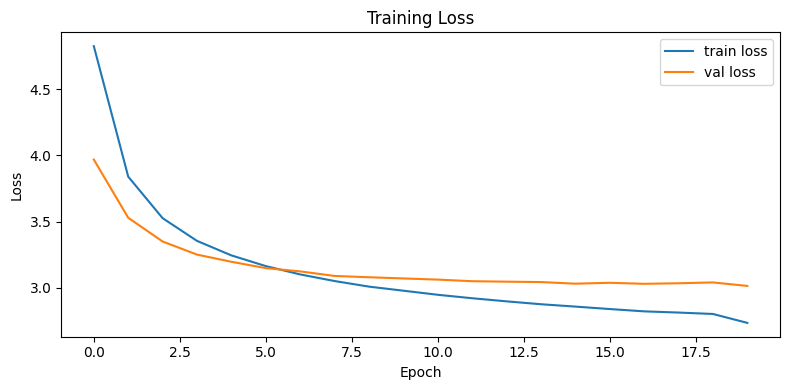

Training complete.


In [12]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

callbacks = [
    ModelCheckpoint(
        str(OUTPUT_DIR / 'best_model.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,               # more patience for larger model
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,               # halve LR when stuck
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'training_loss.png'), dpi=150)
plt.show()
print('Training complete.')

# Step 7 — Generate Captions

In [13]:
def greedy_caption(img_name: str) -> str:
    """Fast greedy search — used for generating all 8091 captions."""
    feat = features[img_name].reshape(1, -1)
    seq  = [word_to_idx['startseq']]
    for _ in range(max_len):
        in_seq  = np.array([pad_seq(seq, max_len)], dtype=np.int32)
        preds   = model.predict([feat, in_seq], verbose=0)[0]
        next_id = int(np.argmax(preds))
        word    = idx_to_word.get(next_id, '')
        if word == 'endseq' or not word:
            break
        seq.append(next_id)
    return ' '.join(idx_to_word.get(i, '') for i in seq[1:])


def beam_search_caption(img_name: str, beam_width: int = 3) -> str:
    """Beam search — better quality, used for BLEU evaluation and demo."""
    feat = features[img_name].reshape(1, -1)

    # Each beam: (cumulative_neg_log_prob, token_sequence)
    beams     = [(0.0, [word_to_idx['startseq']])]
    completed = []

    for _ in range(max_len):
        if not beams:
            break
        # Batch all current beams into one predict call
        seqs  = np.array([pad_seq(seq, max_len) for _, seq in beams], dtype=np.int32)
        feats = np.repeat(feat, len(beams), axis=0)
        all_preds = model.predict([feats, seqs], verbose=0)  # (n_beams, vocab_size)

        candidates = []
        for b, (score, seq) in enumerate(beams):
            preds = all_preds[b]
            top_k = np.argsort(preds)[-beam_width:]
            for idx in top_k:
                new_score = score - np.log(preds[idx] + 1e-10)
                new_seq   = seq + [int(idx)]
                if idx_to_word.get(int(idx), '') == 'endseq':
                    completed.append((new_score, new_seq))
                else:
                    candidates.append((new_score, new_seq))

        beams = sorted(candidates, key=lambda x: x[0])[:beam_width]

    completed.extend(beams)
    if not completed:
        return ''

    best_seq = min(completed, key=lambda x: x[0])[1]
    words = []
    for i in best_seq[1:]:
        word = idx_to_word.get(i, '')
        if word == 'endseq':
            break
        if word:
            words.append(word)
    return ' '.join(words)


# Sanity check on 3 validation images (using beam search)
print('Sample generated captions (beam search, width=3):\n')
for name in val_names[:3]:
    cap = beam_search_caption(name)
    print(f'  {name}')
    print(f'  Generated : {cap}')
    print(f'  Reference : {captions_dict[name][0]}')
    print()

Sample generated captions (beam search, width=3):

  436015762_8d0bae90c3.jpg
  Generated : a man in a red shirt is climbing a rock wall
  Reference : A man prepares to enter the red building .

  436393371_822ee70952.jpg
  Generated : a brown dog is running through the grass
  Reference : A brown doberman is outside with a stick in its mouth .

  436608339_f1d1298770.jpg
  Generated : a man in a red shirt is standing in a parade
  Reference : a couple posing in front of a picture wall



# Step 8 — BLEU Evaluation

In [14]:
references = []
hypotheses = []

eval_names = [n for n in val_names[:200] if n in features]

for img_name in eval_names:
    refs = [clean(c).split()[1:-1] for c in captions_dict.get(img_name, [])]
    hyp  = beam_search_caption(img_name, beam_width=3).split()   # beam search
    references.append(refs)
    hypotheses.append(hyp)

bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0))
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))

print(f'BLEU-1 : {bleu1:.4f}')
print(f'BLEU-4 : {bleu4:.4f}')

BLEU-1 : 0.5945
BLEU-4 : 0.1720


# Step 9 — Save Outputs

In [16]:
model.save(str(OUTPUT_DIR / 'lstm_decoder.keras'))

tokenizer_data = {
    'word_to_idx': word_to_idx,
    'idx_to_word': {str(k): v for k, v in idx_to_word.items()},
    'max_len':     int(max_len),
    'vocab_size':  int(vocab_size)
}
with open(OUTPUT_DIR / 'tokenizer.json', 'w', encoding='utf-8') as f:
    json.dump(tokenizer_data, f, indent=2)

# Generate captions for ALL images using greedy (fast) for the handoff file
print('Generating captions for all images (greedy)...')
all_generated = {}
for i, img_name in enumerate(features):
    all_generated[img_name] = greedy_caption(img_name)
    if (i + 1) % 500 == 0:
        print(f'  {i + 1}/{len(features)} done')

with open(OUTPUT_DIR / 'generated_captions.json', 'w', encoding='utf-8') as f:
    json.dump(all_generated, f, indent=2)

print(f'\nAll outputs saved to {OUTPUT_DIR}')
print(f'  lstm_decoder.keras')
print(f'  tokenizer.json')
print(f'  generated_captions.json  ({len(all_generated)} captions)')

Generating captions for all images (greedy)...
  500/8091 done
  1000/8091 done
  1500/8091 done
  2000/8091 done
  2500/8091 done
  3000/8091 done
  3500/8091 done
  4000/8091 done
  4500/8091 done
  5000/8091 done
  5500/8091 done
  6000/8091 done
  6500/8091 done
  7000/8091 done
  7500/8091 done
  8000/8091 done

All outputs saved to /content/drive/MyDrive/Healix/outputs/decoder
  lstm_decoder.keras
  tokenizer.json
  generated_captions.json  (8091 captions)


 `My Drive/Healix/outputs/decoder/generated_captions.json`

```python
import json
with open('generated_captions.json') as f:
    captions = json.load(f)
english_sentences = list(captions.values())  # list of strings to translate
```